# 05 — Modélisation : réseau LSTM (FD001)

**Objectif** : entraîner un réseau de neurones récurrent (LSTM) sur les séquences de 30 cycles, capable d'apprendre directement la dynamique temporelle de la dégradation, et sauvegarder ses prédictions pour comparaison avec les approches précédentes.

In [1]:
# --- Imports et configuration ---
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

SUBSET = "FD001"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "dl"
MODELS_DIR = PROJECT_ROOT / "models" / "dl"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / "reports" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "modelisation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
X_train = np.load(PROCESSED_DIR / f"X_train_{SUBSET}.npy")
y_train = np.load(PROCESSED_DIR / f"y_train_{SUBSET}.npy")
unit_ids_train = np.load(PROCESSED_DIR / f"unit_ids_train_{SUBSET}.npy")
X_test = np.load(PROCESSED_DIR / f"X_test_{SUBSET}.npy")
y_test = np.load(PROCESSED_DIR / f"y_test_{SUBSET}.npy")

WINDOW = X_train.shape[1]
N_CAPTEURS = X_train.shape[2]

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

X_train : (17731, 30, 15)
X_test  : (100, 30, 15)


## 1. Séparation train / validation

Même logique que pour les modèles précédents : le découpage se fait par moteur entier, pas par séquence, pour que les séquences chevauchantes d'un même moteur ne se retrouvent jamais scindées entre apprentissage et validation.

In [3]:
separateur = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train, idx_val = next(separateur.split(X_train, groups=unit_ids_train))

X_tr, y_tr = X_train[idx_train], y_train[idx_train]
X_val, y_val = X_train[idx_val], y_train[idx_val]

print(f"Apprentissage : {X_tr.shape[0]} sequences, {len(set(unit_ids_train[idx_train]))} moteurs")
print(f"Validation    : {X_val.shape[0]} sequences, {len(set(unit_ids_train[idx_val]))} moteurs")

Apprentissage : 14241 sequences, 80 moteurs
Validation    : 3490 sequences, 20 moteurs


**Interprétation** : même principe que pour les modèles précédents — le découpage se fait par moteur entier, pas par séquence, pour éviter que des séquences très proches d'un même moteur se retrouvent scindées entre les deux ensembles.

## 2. Architecture et entraînement

Le réseau empile deux couches LSTM (64 puis 32 unités), avec du dropout entre elles pour limiter le surapprentissage, suivies de couches denses pour produire une seule valeur de sortie : la RUL. L'entraînement s'arrête automatiquement si la performance sur la validation cesse de s'améliorer.

In [4]:
modele = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, N_CAPTEURS)),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(32),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1),
])

modele.compile(optimizer="adam", loss="mse", metrics=["mae"])
modele.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,441 (130.63 KB)

 Trainable params: 33,441 (130.63 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
arret_precoce = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

historique = modele.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[arret_precoce],
    verbose=2,
)

Epoch 1/100


446/446 - 12s - 27ms/step - loss: 3983.6777 - mae: 53.1633 - val_loss: 1752.1351 - val_mae: 37.3480


Epoch 2/100


446/446 - 9s - 20ms/step - loss: 1793.1448 - mae: 37.4725 - val_loss: 1743.5033 - val_mae: 37.0395


Epoch 3/100


...

446/446 - 12s - 28ms/step - loss: 222.8279 - mae: 11.0381 - val_loss: 142.2273 - val_mae: 8.3528


Epoch 23/100


446/446 - 12s - 26ms/step - loss: 219.3516 - mae: 10.9266 - val_loss: 155.4543 - val_mae: 8.8163


Epoch 24/100


446/446 - 11s - 25ms/step - loss: 215.9215 - mae: 10.8468 - val_loss: 137.1419 - val_mae: 8.0465


**Interprétation** : l'arrêt précoce a interrompu l'entraînement dès que la perte de validation a cessé de s'améliorer pendant plusieurs époques d'affilée, en restaurant automatiquement les poids de la meilleure époque rencontrée.

## 3. Courbe d'apprentissage

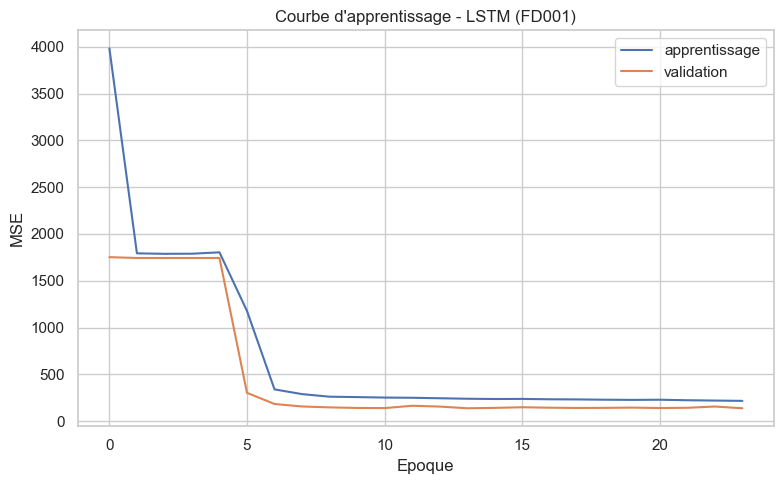

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(historique.history["loss"], label="apprentissage")
ax.plot(historique.history["val_loss"], label="validation")
ax.set_xlabel("Epoque")
ax.set_ylabel("MSE")
ax.set_title(f"Courbe d'apprentissage - LSTM ({SUBSET})")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lstm_courbe_apprentissage.png")
plt.show()

**Interprétation** : la perte chute très vite sur les deux courbes puis se stabilise, sans écart croissant entre apprentissage et validation — pas de signe de surapprentissage marqué sur cette durée d'entraînement.

## 4. Évaluation sur la validation

In [7]:
predictions_val = modele.predict(X_val, verbose=0).flatten()

rmse_val = root_mean_squared_error(y_val, predictions_val)
mae_val = mean_absolute_error(y_val, predictions_val)

print(f"RMSE (validation) : {rmse_val:.2f} cycles")
print(f"MAE (validation)  : {mae_val:.2f} cycles")

RMSE (validation) : 11.71 cycles
MAE (validation)  : 8.22 cycles


**Interprétation** : le LSTM atteint un RMSE de 11,71 cycles et un MAE de 8,22 cycles sur la validation — nettement meilleur que le Random Forest et XGBoost (autour de 17 cycles de RMSE). La normalisation par moteur utilisée au départ faussait la performance réelle des trois modèles sur le test ; on est passé à un MinMaxScaler global, ajusté une seule fois sur le train. Contrairement aux deux autres modèles, les résultats du LSTM ont très peu bougé avec ce changement — il semble moins sensible à l'échelle absolue des valeurs, probablement parce qu'il apprend surtout à partir de la forme de l'évolution dans le temps plutôt que de seuils sur des valeurs isolées.

## 5. Prédictions sur le test et sauvegarde

In [8]:
predictions_test = modele.predict(X_test, verbose=0).flatten()

resultats_test = pd.DataFrame({
    "unit_number": np.arange(1, len(y_test) + 1),
    "RUL_reelle": y_test,
    "RUL_predite": predictions_test,
})
resultats_test.to_csv(RESULTS_DIR / f"predictions_lstm_{SUBSET}.csv", index=False)

modele.save(MODELS_DIR / f"lstm_{SUBSET}.keras")

print("Predictions et modele sauvegardes.")
resultats_test.head()

Predictions et modele sauvegardes.


,unit_number,RUL_reelle,RUL_predite
0,1,112,113.726608
1,2,98,119.417664
2,3,69,48.611866
3,4,82,74.475822
4,5,91,100.320534


## Synthèse

Le LSTM a été entraîné directement sur les séquences brutes, avec le même principe de séparation par moteur que les modèles précédents. Ses prédictions sur le test sont sauvegardées dans `reports/results/`, aux côtés de celles du Random Forest et de XGBoost.